# SPARC Example 04: WALLABY Tier 2 — Automated Pipeline with Caution Zone

**EPS Research RAG Astrophysics Corpus — Unified HI Corpus v7.0**

WALLABY DR2 contributes 203 galaxies from the ASKAP automated pipeline.
Unlike SPARC/THINGS/LITTLE THINGS (Tier 1), WALLABY is Tier 2:
no per-ring uncertainties, no baryonic decomposition.

Key limitation: 30 arcsec ASKAP beam — Vrot < 50 km/s is unreliable.

Schema difference: WALLABY uses `rotation_curve` key with `rad_kpc`/`vrot_kms`.
SPARC uses `data` key with `Rad`/`Vobs`. Always check the survey.

**Important note on corpus fidelity:** The `rotation_curve_corpus_v7_flat.csv` and `rotation_curve_corpus_v7.json` are **full-fidelity** — not a summary or veneer. The CSV contains every kinematic parameter published by Lelli et al. (2016) including per-galaxy inclination, distance uncertainties, mass-to-light ratios, and rotation curve statistics. The JSON adds full per-ring data: Vobs, Vgas, Vdisk, Vbul, errV at every radial point. This is the complete published dataset in a single machine-readable file.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19563417  
**Source:** Lelli, McGaugh & Schombert (2016), AJ 152, 157  
**Dependencies:** Python 3, numpy, matplotlib, csv (standard library only)

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'rotation_curve_corpus_v7.json': 'https://zenodo.org/records/19563417/files/rotation_curve_corpus_v7.json',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('rotation_curve_corpus_v7.json') as f:
    corpus = json.load(f)

# Find a WALLABY galaxy with many rings
wallaby = [g for g in corpus['galaxies']
           if g['survey'] == 'WALLABY'
           and g.get('rotation_curve')
           and len(g['rotation_curve']) >= 20]
wg = sorted(wallaby, key=lambda x: len(x['rotation_curve']), reverse=True)[0]

print(f"Galaxy:      {wg['galaxy']}")
print(f"Survey:      {wg['survey']} (Tier {wg['quality_tier']})")
print(f"Distance:    {wg['distance_mpc']} Mpc")
print(f"Inclination: {wg['inc_deg']} deg")
print(f"N rings:     {len(wg['rotation_curve'])}")
print(f"\nKey schema difference:")
print(f"  WALLABY: rotation_curve -> rad_kpc, vrot_kms")
print(f"  SPARC:   data           -> Rad, Vobs")

Galaxy:      WALLABY_J125548+041805
Survey:      WALLABY (Tier 2)
Distance:    10.08 Mpc
Inclination: 76.47 deg
N rings:     47

Key schema difference:
  WALLABY: rotation_curve -> rad_kpc, vrot_kms
  SPARC:   data           -> Rad, Vobs


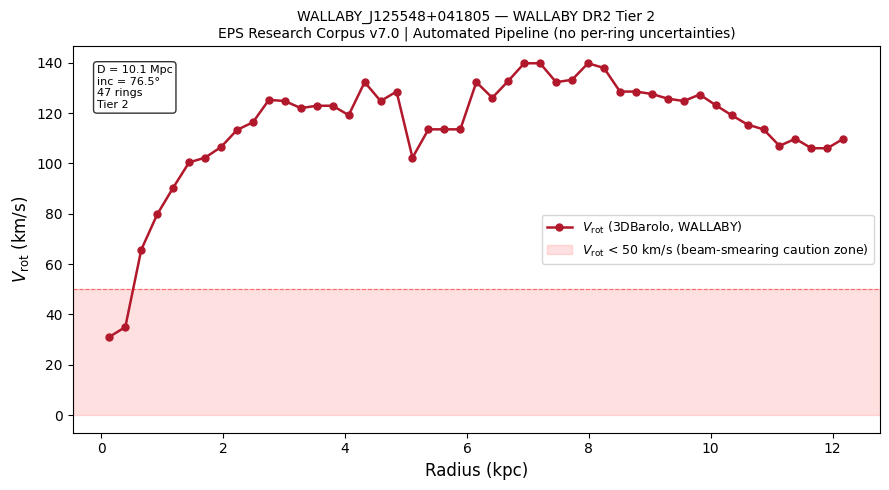

In [3]:
rc  = wg['rotation_curve']
R_w = np.array([p['rad_kpc']  for p in rc])
V_w = np.array([p['vrot_kms'] for p in rc])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(R_w, V_w, 'o-', color='#B2182B', linewidth=1.8, markersize=5,
        label=r'$V_{\rm rot}$ (3DBarolo, WALLABY)')
ax.axhspan(0, 50, alpha=0.12, color='red',
           label=r'$V_{\rm rot}$ < 50 km/s (beam-smearing caution zone)')
ax.axhline(50, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Radius (kpc)', fontsize=12)
ax.set_ylabel(r'$V_{\rm rot}$ (km/s)', fontsize=12)
ax.set_title(f'{wg["galaxy"]} — WALLABY DR2 Tier 2\n'
             'EPS Research Corpus v7.0 | Automated Pipeline (no per-ring uncertainties)',
             fontsize=10)
ax.legend(fontsize=9)
ax.text(0.03, 0.95,
        f'D = {wg["distance_mpc"]:.1f} Mpc\n'
        f'inc = {wg["inc_deg"]:.1f}°\n'
        f'{len(rc)} rings\nTier 2',
        transform=ax.transAxes, va='top', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
plt.tight_layout()
plt.savefig('ex04_wallaby_tier2.png', dpi=150, bbox_inches='tight')
plt.show()